In [44]:
import scanpy as sc
import pandas as pd
from matplotlib import pyplot as plt
import os
import numpy as np
from matplotlib import rcParams
import seaborn as sns
import anndata as ad
os.chdir(os.getcwd())
import pickle

# Load raw data

In [10]:
adata.layers['cellbender']
adata_sample.var
len(l)

33

In [46]:
#adata=sc.read_h5ad('../data/prelim_analysis.h5ad')

## Read metadata
metadata=pd.read_excel('../../data/Sample_Names_050823.xlsx',
                        sheet_name='metadata',index_col=0) 
metadata['batch']=metadata['batch'].astype(str) 

## Create list of sample names
sample_names=(metadata['patient']+'_'+metadata['condition']).values.tolist()



base_dir='../../aligned_data'

adata_dict={}


## AS BARCODES ARE UNIQUE WITHIN A SAMPLE, BUT NOT ACROSS MULTIPLE SAMPLES, THERE WIL BE DUPLICATED BARCODE NAMES
#  TO MAKE IT POSSIBLE TO ALIGN THE COUNT MATRIX BARCODES WITH THE VELOCYTO OUTPUT BARCODES, CREATE LOOKUP TABLE 
#  OF PER SAMPLE BARCODES AND UNIQUE BARCODES ACROSS MULTIPLE SAMPLES
barcode_lookup_dict={}


for intron_status in ['with_intron','without_intron'][:]:
    adata_dict[intron_status]={}
    barcode_lookup_dict[intron_status]={}

    
    for ref_genome in os.listdir('../../data/cellbender_output'): 

        #print(ref_genome,intron_status)

        ref_genome_=os.path.join(ref_genome,intron_status)

        lll=[]
        l=[]
        if not ref_genome_.startswith('.'):
            for batch in ['Batch1','Batch2','Batch3','Batch4','Batch5','Batch6']: #os.listdir('../../data/cellbender_output/'+ref_genome):
                if not batch.startswith('.'):
                    #print(batch)
                    for sample_name in sample_names:
                        
                        input_file=os.path.join('../../data/cellbender_corrected_counts','_'.join([ref_genome,intron_status,batch,
                                                                                                   sample_name,'cellbender_corrected.h5ad']))
                        #print(input_file)
                        if os.path.isfile(input_file):    
                            #input_file=os.path.join('../../data','_'.join([ref_genome,batch,'cellbender_corrected.h5ad']))
                            adata_sample=sc.read_h5ad(input_file)
                            adata_sample.obs['original_sample']=sample_name

                            # Create column with unique cell numbers (concatenate sample name as prefix, to make them unique across multiple samples)
                            adata_sample.obs['cell_number']=np.arange(0,len(adata_sample.obs))
                            adata_sample.obs['cell_number']=adata_sample.obs['original_sample']+'_'+adata_sample.obs['cell_number'].astype(str)
                            
                            ## Make barcodes unique by
                            #adata_sample.obs_names_make_unique()
       
                            #print('Num of - in index:',len(adata_sample.obs.reset_index()['barcode'].str.split('-',expand=True).columns))
                            
                            adata_sample.var_names_make_unique()
                            print(ref_genome,intron_status,sample_name,adata_sample.shape[0],'cells')
                            l.append(adata_sample)
                            #print(len(l))
            #print(len(l))
            
            if len(l)>0:
                adata=ad.concat(l,merge='same')

                ## Save dataframe of unique cell number - sample level barcodes BEFORE making any duplicated sample level barcode unique
                #. with .obs_names_make_unique()
                cell_id_barcode_df=adata.obs[['cell_number']].reset_index().set_index('cell_number')
                lll.append(cell_id_barcode_df)
                
                adata.obs_names_make_unique()

                ## Save dataframe of unique cell number - sample level barcodes AFTER making any duplicated sample level barcode unique
                #. with .obs_names_make_unique()
                cell_id_barcode_df=adata.obs[['cell_number']].reset_index().set_index('cell_number')
                lll.append(cell_id_barcode_df)
                
                print('Num of - in index:',len(adata.obs.reset_index()['barcode'].str.split('-',expand=True).columns))
                adata=adata[adata.obs['cell_probability']>0.5,:].copy()
                adata.X=adata.layers['cellbender']
                adata_dict[intron_status][ref_genome]=adata

                ## Save barcode lookup table for later use with velocyto outputs
                barcode_df = pd.concat(lll,axis=1)
                barcode_df.columns=['barcode_sample_level','barcode_dataset_level']
                barcode_lookup_dict[intron_status][ref_genome] = barcode_df



fn=os.path.join('../../data/barcode_lookup_table_across_alignment_and_velocyto.pickle')
with open(fn, 'wb') as handle:
    pickle.dump(barcode_lookup_dict, handle)
  

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable nam

GRCh38-p14-Gencode_v44 with_intron CAR1_D 10412 cells
GRCh38-p14-Gencode_v44 with_intron CAR2_H 5969 cells
GRCh38-p14-Gencode_v44 with_intron CAR2_D 2598 cells
GRCh38-p14-Gencode_v44 with_intron CAR3_H 3397 cells
GRCh38-p14-Gencode_v44 with_intron CAR3_D 3355 cells


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable nam

GRCh38-p14-Gencode_v44 with_intron CAR4_H 3007 cells
GRCh38-p14-Gencode_v44 with_intron CAR4_D 2983 cells
GRCh38-p14-Gencode_v44 with_intron CAR5_H 2987 cells
GRCh38-p14-Gencode_v44 with_intron CAR5_D 3276 cells
GRCh38-p14-Gencode_v44 with_intron CAR6_H 5191 cells
GRCh38-p14-Gencode_v44 with_intron CAR6_D 2862 cells
GRCh38-p14-Gencode_v44 with_intron CAR7_H 15424 cells


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


...

GRCh38-p14-Gencode_v44 with_intron CAR17_D 168 cells


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Num of - in index: 3
GRCh38-p14-Gencode_v44 without_intron CAR1_D 10602 cells
GRCh38-p14-Gencode_v44 without_intron CAR2_H 5135 cells
GRCh38-p14-Gencode_v44 without_intron CAR2_D 2788 cells
GRCh38-p14-Gencode_v44 without_intron CAR3_H 3627 cells
GRCh38-p14-Gencode_v44 without_intron CAR3_D 3349 cells
GRCh38-p14-Gencode_v44 without_intron CAR4_H 3060 cells
GRCh38-p14-Gencode_v44 without_intron CAR4_D 3140 cells
GRCh38-p14-Gencode_v44 without_intron CAR5_H 1269 cells
GRCh38-p14-Gencode_v44 without_intron CAR5_D 2500 cells
GRCh38-p14-Gencode_v44 without_intron CAR6_H 6005 cells
GRCh38-p14-Gencode_v44 without_intron CAR6_D 3301 cells
GRCh38-p14-Gencode_v44 without_intron CAR7_H 16044 cells
GRCh38-p14-Gencode_v44 without_intron CAR7_D 2968 cells
GRCh38-p14-Gencode_v44 without_intron CAR8_H 3802 cells
GRCh38-p14-Gencode_v44 without_intron CAR8_D 1575 cells
GRCh38-p14-Gencode_v44 without_intron CAR9_H 6954 cells
GRCh38-p14-Gencode_v44 without_intron CAR9_D 7264 cells
GRCh38-p14-Gencode_v44 wi

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Num of - in index: 3


In [42]:
barcode_df = barcode_lookup_dict['with_intron']['GRCh38-p14-Gencode_v44']#.keys()
barcode_df['barcode_dataset_level'].str.split('-',expand=True)[2].dropna()

cell_number
CAR2_D_0       1
CAR2_D_1       1
CAR2_D_2       1
CAR2_D_3       1
CAR2_D_4       1
              ..
CAR17_D_38     1
CAR17_D_46     1
CAR17_D_128    1
CAR17_D_140    1
CAR17_D_161    2
Name: 2, Length: 29326, dtype: object

cell_number
CAR2_H_1192     1
CAR2_D_0        1
CAR2_D_1        1
CAR2_D_2        1
CAR2_D_3        1
               ..
CAR16_H_6254    1
CAR16_H_6260    1
CAR16_H_6261    1
CAR16_H_6277    1
CAR16_H_6355    1
Name: 2, Length: 29563, dtype: object

In [16]:
adata.obs#.reset_index()

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_raw,n_cellbender,patient,condition,batch,ribo_frac,mt_frac,original_sample,cell_number
barcode,,,,,,,,,,,,,
CTGCGGAAGTTTGCGT-1,0.000274,0.999955,22605.736328,2.249228,51186,51172,CAR1,D,1,0.215879,0.020826,CAR1_D,CAR1_D_0
ATCGAGTCATACAGCT-1,0.000231,0.999955,17873.677734,2.429948,43335,43325,CAR1,D,1,0.128695,0.038837,CAR1_D,CAR1_D_1
GTAGTCACATCCCACT-1,0.000478,0.999955,17874.205078,2.219657,39781,39762,CAR1,D,1,0.271939,0.012870,CAR1_D,CAR1_D_2
AGCAGCCCACACATGT-1,0.000411,0.999955,16676.882812,2.182768,36514,36499,CAR1,D,1,0.300487,0.018568,CAR1_D,CAR1_D_3
TTATGCTTCTACTTAC-1,0.000448,0.999955,16200.272461,2.201731,35729,35713,CAR1,D,1,0.322875,0.019480,CAR1_D,CAR1_D_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTAGTCTCATTATCC-1,0.068323,0.999826,329.703705,0.840000,161,150,CAR17,D,6,0.000000,0.000000,CAR17_D,CAR17_D_31
ACCAACAAGCTGGCTC-1,0.232226,0.996698,329.100708,0.821412,211,162,CAR17,D,6,0.454976,0.037915,CAR17_D,CAR17_D_32
GTGACGCAGGCTCACC-1,0.216048,0.989250,318.702881,0.858892,162,127,CAR17,D,6,0.049383,0.753086,CAR17_D,CAR17_D_33


In [ ]:
par_y_genes=adata.var[adata.var['gene_id'].str.contains('PAR_Y')]['gene_id_'].tolist()

def mean_str(col):
    if pd.api.types.is_numeric_dtype(col):
        return col.sum()
    if pd.api.types.is_numeric_dtype(col)==False or col.isna().all():
        return col.unique().tolist()[0] #if col.nunique() == 1 else np.nan

print()

adata.var[adata.var['gene_id_'].isin(par_y_genes)].reset_index().groupby('gene_id_',).agg(mean_str).reset_index().set_index('gene_name')

In [ ]:
adata.var.loc[~adata.var['gene_id_'].isin(par_y_genes),'gene_id'].tolist()


genes_without_par_y

In [3]:
adata_filt_dict={}
for ref_genome in [*adata_dict][:]:


    print(ref_genome)
    adata = adata_dict[ref_genome]
    
    adata.var['gene_id_']=adata.var['gene_id'].str.split('.',expand=True)[0]
    #adata.var['gene_id_']=adata.var['gene_id'].str.split('.',expand=True)[0]


    par_y_genes=adata.var[adata.var['gene_id'].str.contains('PAR_Y')]['gene_id_'].tolist()

    def mean_str(col):
        if pd.api.types.is_numeric_dtype(col):
            return col.sum()
        if pd.api.types.is_numeric_dtype(col)==False or col.isna().all():
            return col.unique().tolist()[0] #if col.nunique() == 1 else np.nan
    
    if len(par_y_genes)>0:
        
        summed_par_genes = adata.var[adata.var['gene_id_'].isin(par_y_genes)].reset_index().groupby('gene_id_',).agg(mean_str).reset_index().set_index('gene_name')

        non_par_genes=adata.var.loc[~adata.var['gene_id_'].isin(par_y_genes)]#,'gene_id'].tolist()

        genes_without_par_y=summed_par_genes['gene_id'].tolist() + non_par_genes['gene_id'].tolist()
        
        adata_=adata[:,adata.var['gene_id'].isin(genes_without_par_y)]
        adata_.var=pd.concat([adata.var[~adata.var['gene_id_'].isin(par_y_genes)],summed_par_genes],axis=0).copy()

        adata=adata_.copy()

    adata.var['n_cells_raw']=(adata.layers['raw']>0).sum(axis=0).A1  
    adata.var['n_counts_raw']=(adata.layers['raw']).sum(axis=0).A1  
    genes=adata.var['n_cells_raw'][adata.var['n_cells_raw']>-10].index.tolist()
    
    #print(adata.var['gene_id'].unique().shape)
    adata_filt=adata[:,genes]

    print(adata_filt.shape)

    adata_filt_dict[ref_genome]=adata_filt
    

GRCh38-p14-Gencode_v44
(37075, 39583)
GRCh38-p13-Gencode_v33
(38428, 60676)


In [4]:
adata_44 = adata_filt_dict[[*adata_dict][0]].copy()
adata_33 = adata_filt_dict[[*adata_dict][1]].copy()


comm_genes=adata_44.var[adata_44.var['gene_id_'].isin(adata_33.var['gene_id_'])]['gene_id'].unique()
#adata_33.var[~adata_33.var['gene_id_'].isin(adata_44.var['gene_id_'])]
adata_44.var=adata_44.var.reset_index().set_index('gene_id_',drop=False)
adata_33.var=adata_33.var.reset_index().set_index('gene_id_',drop=False)


a=(adata_44.var.loc[comm_genes,'n_counts_raw'] - adata_33.var.loc[comm_genes,'n_counts_raw'])

#adata.var#[adata.var['gene_id_'].duplicated(keep=False)].sort_values(by=['gene_id_'])

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


(3001, 4)


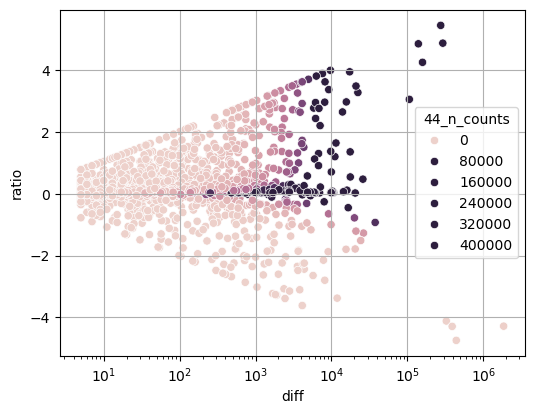

In [7]:
a=np.log10(adata_44.var.loc[comm_genes,'n_counts_raw']/adata_33.var.loc[comm_genes,'n_counts_raw'])
#a=abs(1- abs(adata_33.var.loc[comm_genes,'n_counts_raw']/adata_44.var.loc[comm_genes,'n_counts_raw']))
b=abs(adata_44.var.loc[comm_genes,'n_counts_raw']-adata_33.var.loc[comm_genes,'n_counts_raw'])
c=pd.concat([a,b,adata_44.var.loc[comm_genes,'n_counts_raw'],adata_33.var.loc[comm_genes,'n_counts_raw']],axis=1)
c.columns=['ratio','diff','44_n_counts','33_n_counts']


high_thr=np.log10(1.1)
low_thr=np.log10(0.9)
c=c[(c['diff'].abs()>=5)\
    #&(c['44_n_counts']>=5)\
    &((c['ratio']<low_thr)|(c['ratio']>high_thr))\
    ]
print(c.shape)

#c.hist(bins=1000)
#plt.yscale('log')
#plt.xlim(0,2)
#plt.xscale('log')
fig,ax=plt.subplots(1,1,figsize=(6,4.5))
sns.scatterplot(data=c,x='diff',y='ratio',hue='44_n_counts',ax=ax,hue_norm=(np.percentile(c['44_n_counts'],10),np.percentile(c['44_n_counts'],95)))
#ax.set_yscale('log')
ax.set_xscale('log')
ax.grid()


2283
23376


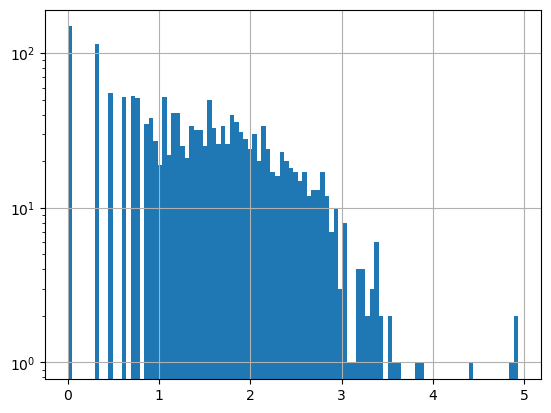

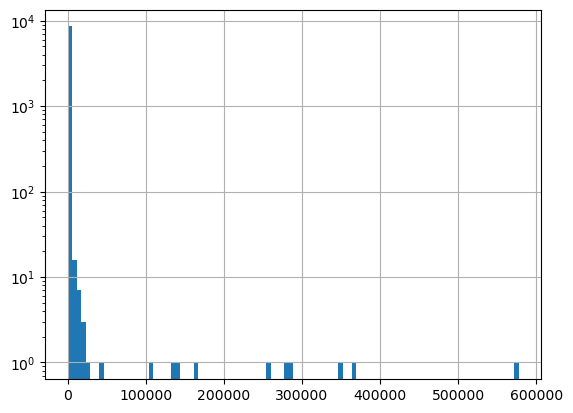

In [31]:
adata_44 = adata_filt_dict[[*adata_dict][0]].copy()
adata_33 = adata_filt_dict[[*adata_dict][1]].copy()


unique_44_genes=adata_44.var[~adata_44.var['gene_id_'].isin(adata_33.var['gene_id_'])]['gene_id'].unique()
unique_33_genes=adata_33.var[~adata_33.var['gene_id_'].isin(adata_44.var['gene_id_'])]['gene_id_'].unique()
#adata_33.var[~adata_33.var['gene_id_'].isin(adata_44.var['gene_id_'])]
adata_44.var=adata_44.var.reset_index().set_index('gene_id_',drop=False)
adata_33.var=adata_33.var.reset_index().set_index('gene_id_',drop=False)


print(len(unique_44_genes))
a=(adata_44.var.loc[unique_44_genes,'n_counts_raw'])
a=np.log10(a[a>0])

a.hist(bins=100)
plt.yscale('log')
#plt.xlim(0,2)
#plt.xscale('log')


print(len(unique_33_genes))
b=(adata_33.var.loc[unique_33_genes,'n_counts_raw'])
b=(b[b>0])

plt.figure()
b.hist(bins=100)
plt.yscale('log')
#plt.xlim(0,2)
#plt.xscale('log')



In [29]:
unique_33_genes

array(['ENSG00000223972.5', 'ENSG00000227232.5', 'ENSG00000278267.1', ...,
       'ENSG00000265658.6', 'ENSG00000275287.5', 'ENSG00000277120.5'],
      dtype=object)

# Normalize data

In [37]:
adata_dict.keys()
adata_dict['without_intron'].keys()

dict_keys(['GRCh38-p14-Gencode_v44'])

In [48]:
adata_norm_dict={}


for intron_status in adata_dict.keys():
    adata_norm_dict[intron_status]={}
    
    for ref_genome,adata in adata_dict[intron_status].items():
        adata_pp = adata.copy()
        sc.pp.normalize_total(adata_pp, target_sum=1e4, exclude_highly_expressed=True)
        sc.pp.log1p(adata_pp)
        print(adata_pp.uns)
        
        adata_norm_dict[intron_status][ref_genome]=adata_pp

/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


OrderedDict([('log1p', {'base': None})])
OrderedDict([('log1p', {'base': None})])


# Plot RBC genes on UMAP

In [49]:
rcParams['figure.figsize']=(6,4.5)

for intron_status in adata_norm_dict.keys():    
    for ref_genome,adata_pp in adata_norm_dict[intron_status].items():
        
        sc.pp.pca(adata_pp,n_comps=30)
        sc.pp.neighbors(adata_pp, n_neighbors=15, n_pcs=30, metric='euclidean')
        sc.tl.umap(adata_pp)
        adata_norm_dict[intron_status][ref_genome]=adata_pp

In [32]:
adata_norm_dict['with_intron'].keys()

dict_keys([])

with_intron
GRCh38-p14-Gencode_v44
without_intron
GRCh38-p14-Gencode_v44


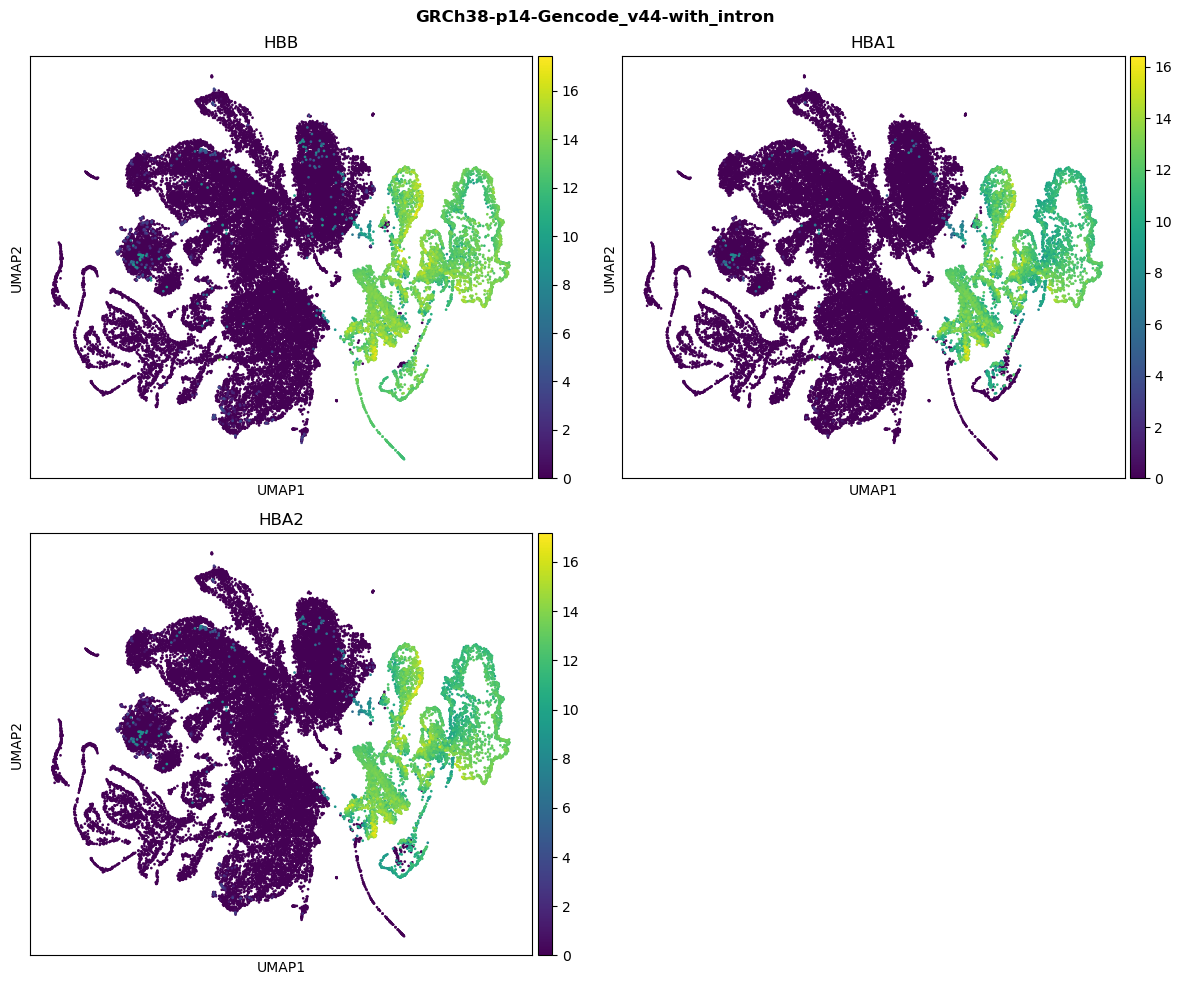

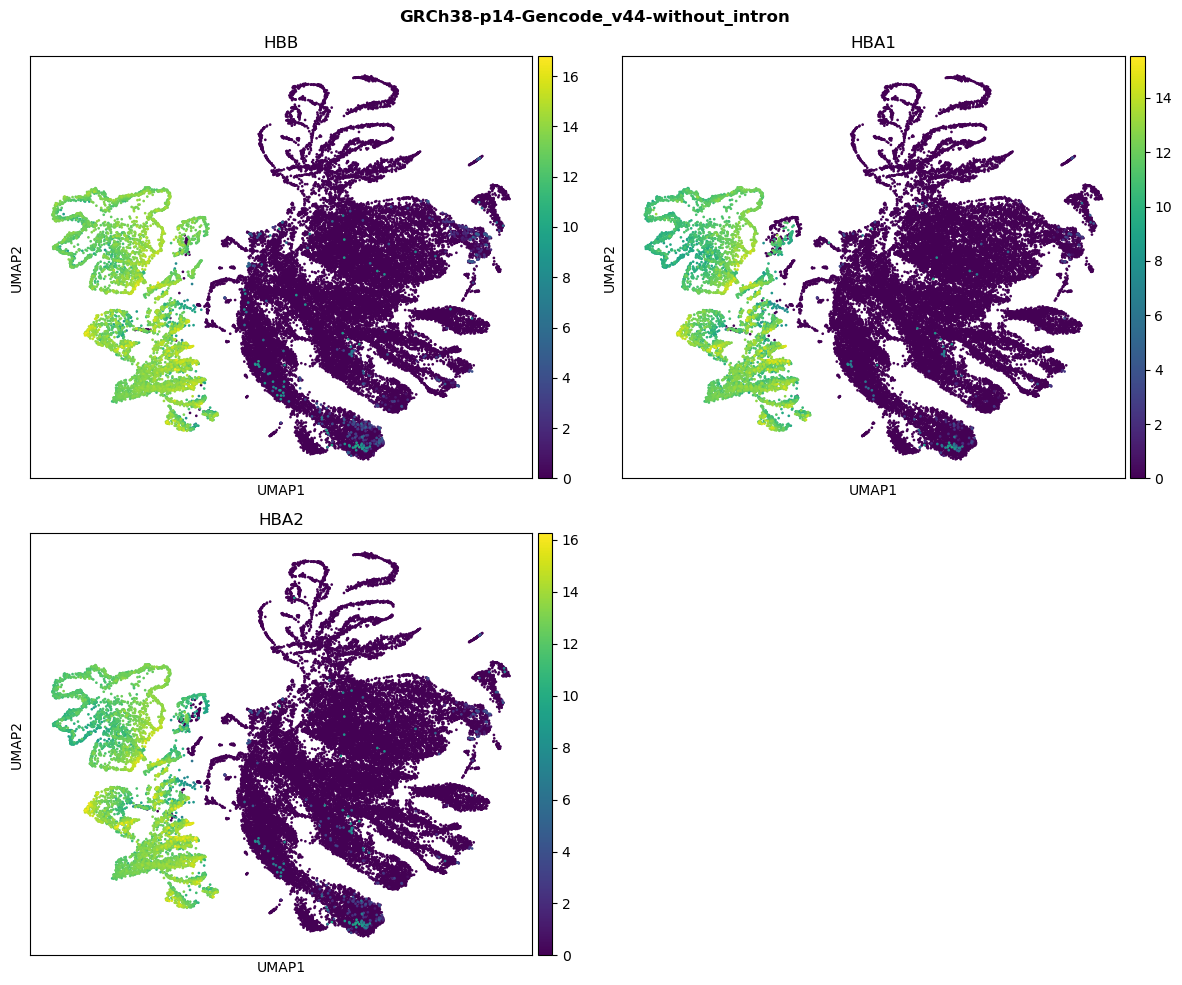

In [53]:
import math
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

ery_genes=['HBB','HBA1','HBA2'][:]#,'HEMGN']
ncols=2
nrows=math.ceil(len(ery_genes)/ncols)

for intron_status in [*adata_norm_dict][:]:
    print(intron_status)
    
    for ref_genome,adata_pp in adata_norm_dict[intron_status].items():
        print(ref_genome)
        
        fig=plt.figure(figsize=(ncols*6,nrows*5))
        fig.suptitle('-'.join([ref_genome,intron_status]),fontweight='bold',y=0.98)
        
        for n,col in enumerate(ery_genes):
            ax=fig.add_subplot(nrows,ncols,n+1)
            sc.pl.umap(adata_pp, color=col,show=False,size=15,ncols=2,ax=ax)
            n=n+1
        fig.tight_layout()    

# Calculate RBC_score

In [54]:
for intron_status in [*adata_norm_dict][:]:
    print(intron_status)
    
    for ref_genome,adata_pp in adata_norm_dict[intron_status].items():
        sc.tl.score_genes(adata_pp, gene_list=ery_genes[0:], score_name='RBC_score')
        adata_norm_dict[intron_status][ref_genome]=adata_pp

with_intron
without_intron


# Plot RBC_score
- Select a RBC_score threshold based on RBC_ascore distribution 
- plot UMAP with low/high RBC_score
- Calculate Leiden-clusters and check which cluster corresponds to high RBC score values

with_intron


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


without_intron


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


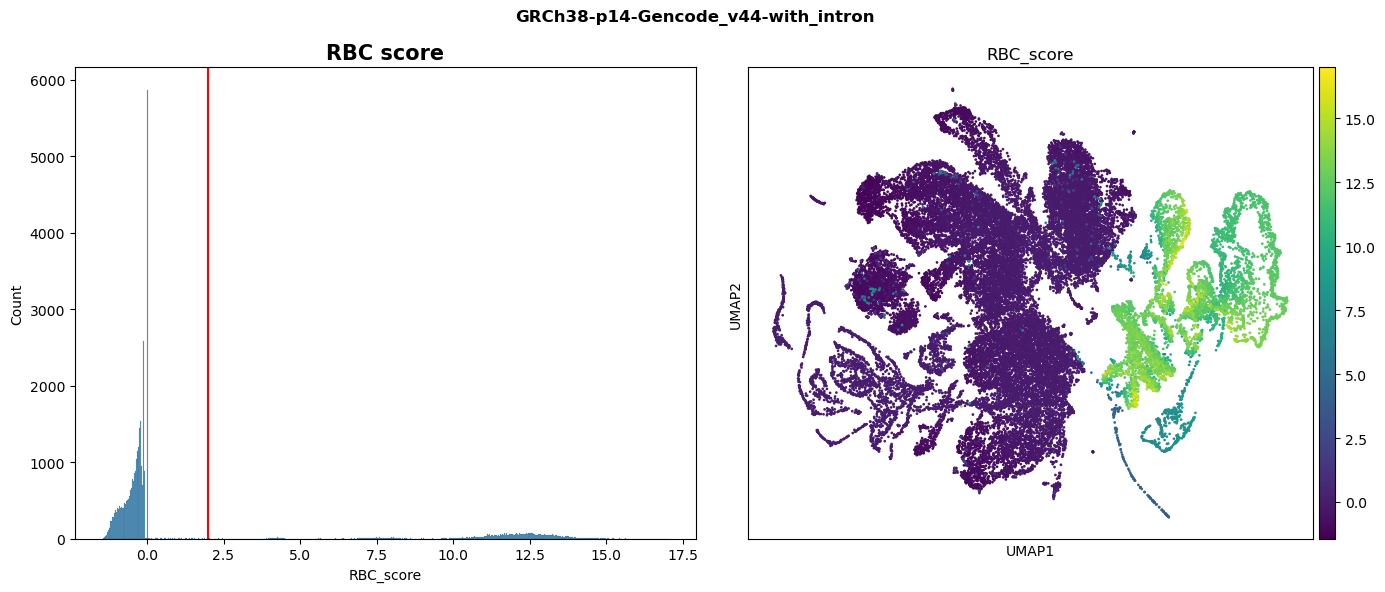

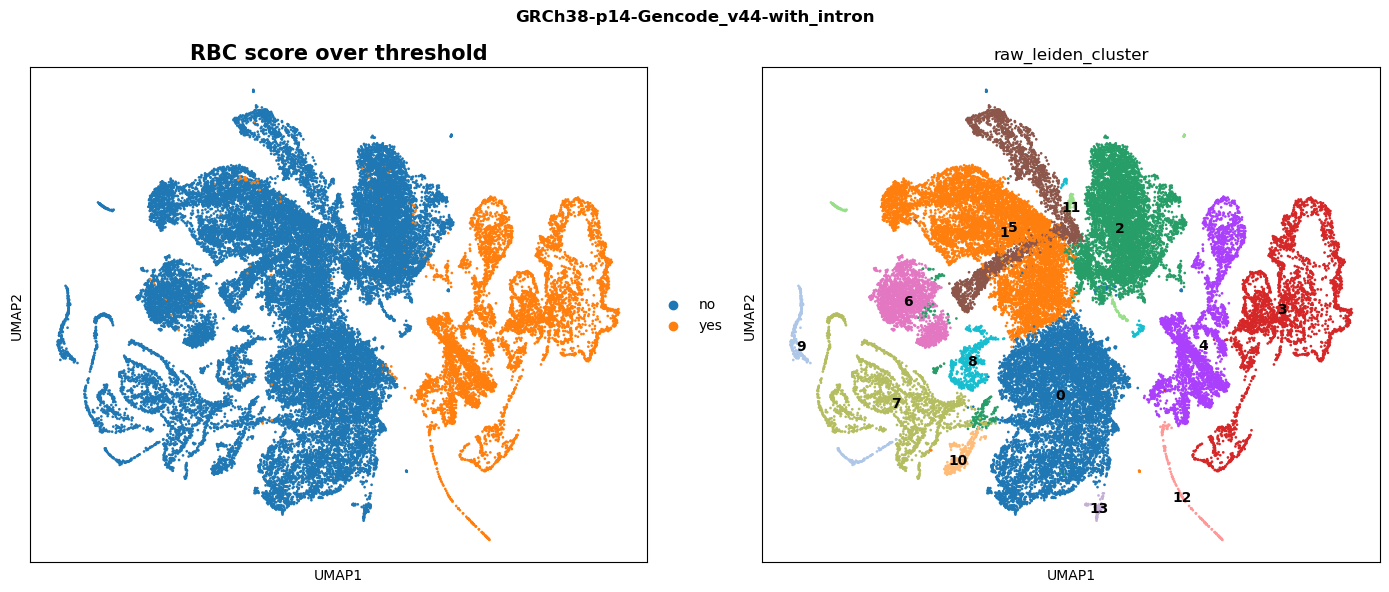

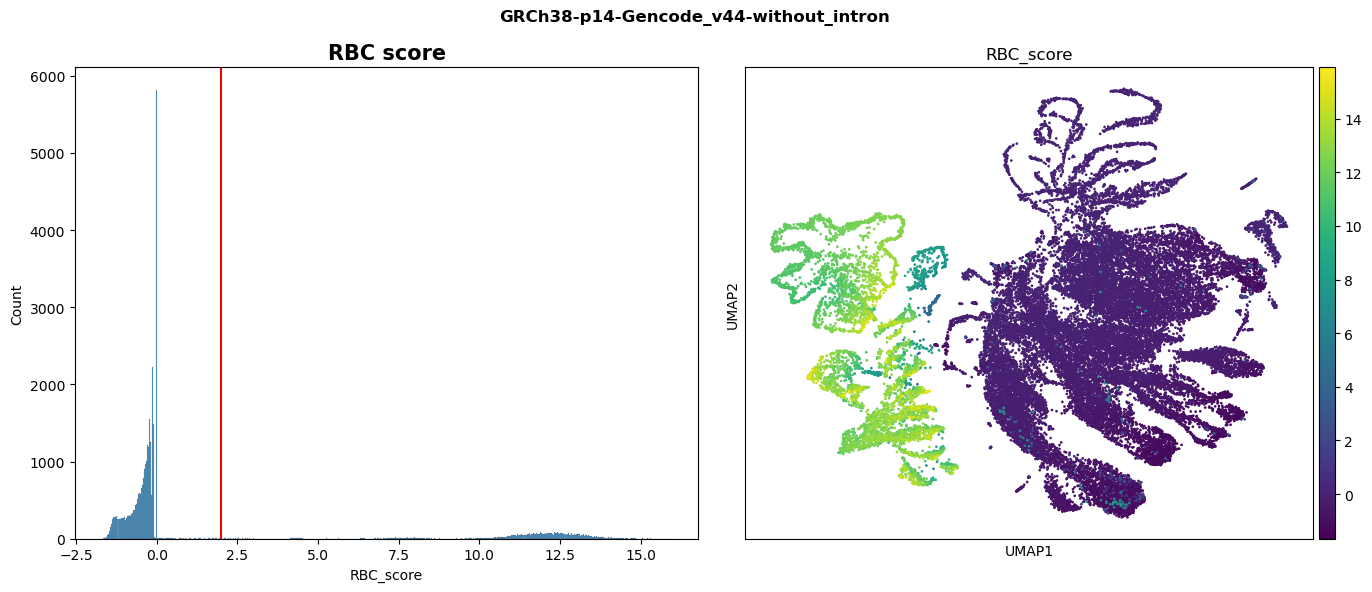

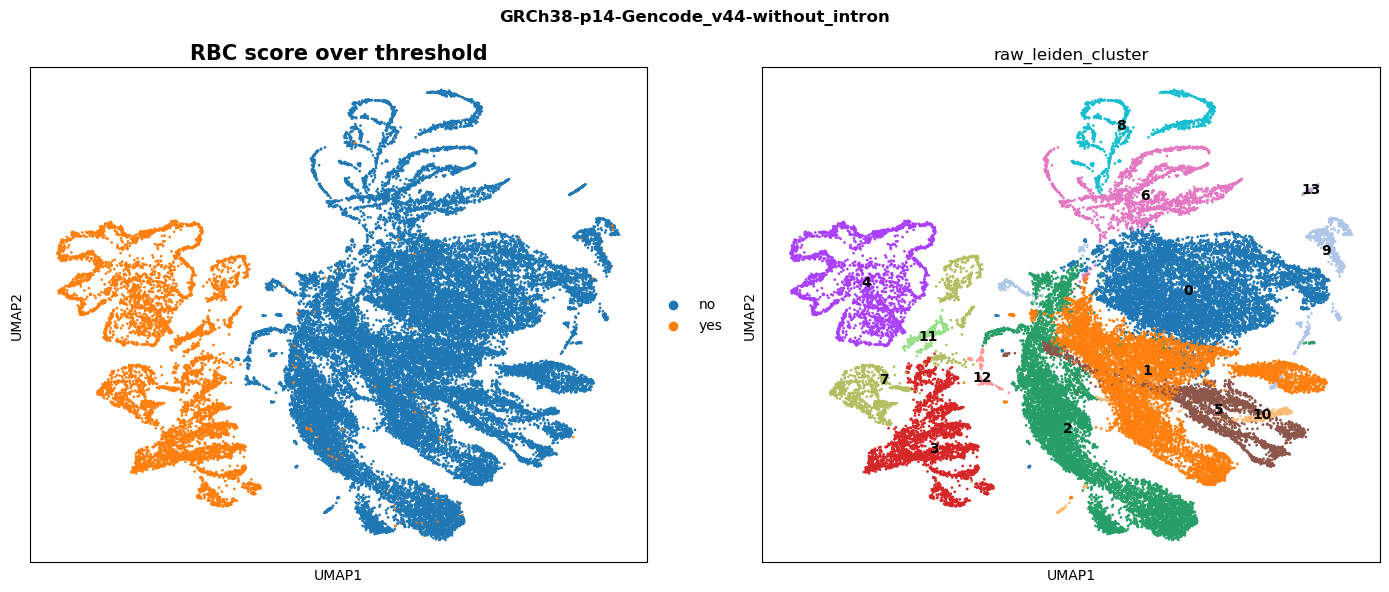

In [56]:
for intron_status in [*adata_norm_dict][:]:
    print(intron_status)
    
    for ref_genome,adata_pp in adata_norm_dict[intron_status].items():
        ## Select rbc score threshold
        rbc_thr=2
        adata_pp.obs['RBC_score_high']='no'
        adata_pp.obs.loc[adata_pp.obs['RBC_score']>rbc_thr,'RBC_score_high']='yes'
    
        fig,ax=plt.subplots(1,2,figsize=(14,6))
        sns.histplot(adata_pp.obs['RBC_score'],ax=ax[0])
        ax[0].axvline(rbc_thr,color='red')
        ax[0].set_title('RBC score',fontsize=15,fontweight='bold')
        fig.suptitle('-'.join([ref_genome,intron_status]),fontweight='bold',y=0.98)
        plt.tight_layout()
    
        sc.pl.umap(adata_pp, color='RBC_score',show=False,size=15,ncols=2,ax=ax[1])
    
        fig,ax=plt.subplots(1,2,figsize=(14,6))
        sc.pl.umap(adata_pp, color='RBC_score_high',show=False,size=15,ncols=2,ax=ax[0])
        ax[0].set_title('RBC score over threshold',fontsize=15,fontweight='bold')
        fig.suptitle('-'.join([ref_genome,intron_status]),fontweight='bold',y=0.98)
    
        #fig,ax=plt.subplots(1,1,figsize=(9,9))
        sc.tl.leiden(adata_pp, key_added='raw_leiden_cluster', resolution=0.1)
        sc.pl.umap(adata_pp, color='raw_leiden_cluster',show=False,size=15,ncols=2,ax=ax[1],legend_loc='on data')
    
        plt.tight_layout()

# Drop the RBCs from the raw adata and save it

In [57]:
## Filter raw adata + save it
for intron_status in [*adata_norm_dict][:]:
    print(intron_status)

    for (ref_genome,adata_pp),adata in zip(adata_norm_dict[intron_status].items(),adata_dict[intron_status].values()):
        print(ref_genome)
        adata_filt=adata[adata_pp.obs['RBC_score_high']=='no',:]
        print(adata_filt)
        adata_filt.write_h5ad(f'../../data/{ref_genome}_{intron_status}_data_RBC_removed.h5ad',compression='gzip')

with_intron
GRCh38-p14-Gencode_v44
View of AnnData object with n_obs × n_vars = 32239 × 39583
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_raw', 'n_cellbender', 'patient', 'condition', 'batch', 'ribo_frac', 'mt_frac', 'original_sample'
    var: 'feature_type', 'genome', 'gene_id'
    obsm: 'cellbender_embedding'
    layers: 'cellbender', 'raw'


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


without_intron
GRCh38-p14-Gencode_v44
View of AnnData object with n_obs × n_vars = 30608 × 39583
    obs: 'background_fraction', 'cell_probability', 'cell_size', 'droplet_efficiency', 'n_raw', 'n_cellbender', 'patient', 'condition', 'batch', 'ribo_frac', 'mt_frac', 'original_sample'
    var: 'feature_type', 'genome', 'gene_id'
    obsm: 'cellbender_embedding'
    layers: 'cellbender', 'raw'


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


In [ ]:
## Check overlapping cells

In [65]:
## Filter raw adata + save it
for intron_status in [*adata_norm_dict][:]:
    print(intron_status)

    for (ref_genome,adata_pp),adata in zip(adata_norm_dict[intron_status].items(),adata_dict[intron_status].values()):
        print(ref_genome)
        adata_filt=adata[adata_pp.obs['RBC_score_high']=='no',:]

        data_fold='../../data/velocyto_concatenate/'
        fname=os.path.join(data_fold,'_'.join([intron_status,ref_genome,'velocyto.h5ad']))
        vc=sc.read_h5ad(fname)

        print(len(list(set(adata_filt.obs.index)&set(vc.obs.index))))
        

with_intron
GRCh38-p14-Gencode_v44
7979
without_intron
GRCh38-p14-Gencode_v44


/data/gpfs/projects/punim2121/anaconda3/envs/scarches/lib/python3.9/site-packages/anndata-0.10.5.post1-py3.9.egg/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '../../data/velocyto_concatenate/without_intron_GRCh38-p14-Gencode_v44_velocyto.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [61]:
adata_filt.obs

,background_fraction,cell_probability,cell_size,droplet_efficiency,n_raw,n_cellbender,patient,condition,batch,ribo_frac,mt_frac,original_sample
barcode,,,,,,,,,,,,
CTGCGGAAGTTTGCGT-1,0.000274,0.999955,22605.736328,2.249228,51186,51172,CAR1,D,1,0.215879,0.020826,CAR1_D
ATCGAGTCATACAGCT-1,0.000231,0.999955,17873.677734,2.429948,43335,43325,CAR1,D,1,0.128695,0.038837,CAR1_D
GTAGTCACATCCCACT-1,0.000478,0.999955,17874.205078,2.219657,39781,39762,CAR1,D,1,0.271939,0.012870,CAR1_D
AGCAGCCCACACATGT-1,0.000411,0.999955,16676.882812,2.182768,36514,36499,CAR1,D,1,0.300487,0.018568,CAR1_D
TTATGCTTCTACTTAC-1,0.000448,0.999955,16200.272461,2.201731,35729,35713,CAR1,D,1,0.322875,0.019480,CAR1_D
...,...,...,...,...,...,...,...,...,...,...,...,...
AGGACGATCCCACCGT-1,0.120419,0.998985,397.316650,0.826486,382,336,CAR17,D,6,0.089005,0.034031,CAR17_D
TCAGGGCGTAGAGTTA-1,0.175257,0.998637,356.985962,0.857705,194,160,CAR17,D,6,0.000000,0.927835,CAR17_D
CCCTCTCAGATCGCTC-1,0.121311,0.996613,344.959595,0.815603,305,268,CAR17,D,6,0.137705,0.055738,CAR17_D


In [64]:
vc.obs

""
CATGCGGAGATCCTAC-1
CCACGAGGTTGCGGAA-1
CATTTCATCGAAGCCC-1
ACTTCGCCAGTCACGC-1
AATTCCTGTTCAAACC-1
...
TGGGTTAAGGTAACTA-1
TGTGGCGGTGATTCTG-1
TTAGGGTAGTGGTTCT-1
TTGCCTGCAGAGTAAT-1
